# Optical Flow on `.cine` Video

This notebook aligns a Phantom `.cine` video with the local `config.json`, applies a manual strip crop, builds a frequency-dependent reference-subtracted version, and compares optical flow on the raw and processed strips side by side.


In [59]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if not (repo_root / "OSCC_postprocessing").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(repo_root)


C:\Users\Jiang\Documents\Mie_Postprocessing_Py


## Configuration


In [82]:
CINE_PATH = Path(r"F:\G\Annoyance\T78_Schlieren Cam_4.cine")

FRAME_LIMIT = 200
FPS = 25_000.0
PAIR_INDEX = 36
BACKEND = "raft"  # "farneback", "nvidia_hw", "raft"

# Nozzle alignment and strip extraction
VIDEO_STRIP_RELATIVE_HEIGHT = 1.0
TARGET_ROW_SLICE = None  # e.g. slice(40, 180)
TARGET_COL_SLICE = None  # e.g. slice(0, 700)
REFERENCE_ROW_SLICE = None  # defaults to top third of the aligned strip
REFERENCE_COL_SLICE = None

# Frequency-dependent subtraction
REFERENCE_TRACE_REDUCER = "median"  # "mean" or "median"
FREQ_DEPENDENT_SMOOTH_BINS = 21
FREQ_SUBTRACT_MAX_HZ = 800.0
CHUNK_PIXELS = 16_384

# Normalize both raw and processed strips before optical flow for a fair comparison
FLOW_NORMALIZE_Q_MIN = 1.0
FLOW_NORMALIZE_Q_MAX = 99.5
PLAYBACK_INTV_MS = 50

BACKEND_KWARGS = {
    "grid_size": 1,
    "preset": "slow",
    "levels": 5,
    "winsize": 15,
}

assert CINE_PATH.exists(), f"File not found: {CINE_PATH}"


## Imports and helpers


In [83]:
import json
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
from numpy.fft import irfft, rfft, rfftfreq

from OSCC_postprocessing.cine.functions_videos import load_cine_video
from OSCC_postprocessing.motion import compute_optical_flows
from OSCC_postprocessing.playback.video_playback import play_videos_side_by_side
from OSCC_postprocessing.rotation.rotate_crop import generate_CropRect
from OSCC_postprocessing.utils.scaling import robust_scale

try:
    import cupy as cp
except Exception:
    cp = None

try:
    from OSCC_postprocessing.rotation.rotate_with_alignment import rotate_video_nozzle_at_0_half_cupy
except Exception:
    rotate_video_nozzle_at_0_half_cupy = None

from OSCC_postprocessing.rotation.rotate_with_alignment_cpu import rotate_video_nozzle_at_0_half_numpy

plt.rcParams["figure.figsize"] = (8, 6)

def load_processing_config(video_path: Path):
    config_path = video_path.parent / "config.json"
    if not config_path.exists():
        raise FileNotFoundError(f"Missing config.json next to video: {video_path}")
    cfg = json.loads(config_path.read_text(encoding="utf-8"))
    required = ["plumes", "offset", "centre_x", "centre_y", "inner_radius", "outer_radius"]
    missing = [key for key in required if key not in cfg]
    if missing:
        raise KeyError(f"config.json missing required fields {missing}: {config_path}")
    return cfg, config_path

def build_aligned_strip(video, cfg, strip_relative_height=1.0):
    n_plumes = int(cfg["plumes"])
    cx = float(cfg["centre_x"])
    cy = float(cfg["centre_y"])
    offset_deg = float(cfg["offset"]) % 360.0
    inner = int(float(cfg["inner_radius"]))
    outer = int(float(cfg["outer_radius"]))

    crop = generate_CropRect(inner, outer, n_plumes, cx, cy)
    frame_h, frame_w = int(video.shape[1]), int(video.shape[2])
    base_crop_h = int(min(max(1, crop[3]), frame_h) / 2)
    crop_h = int(max(1, round(base_crop_h * strip_relative_height)))
    crop_w = int(min(max(1, outer), frame_w))
    out_shape = (crop_h, crop_w)
    calibration_point = (0.0, float(cy))

    if cp is not None and rotate_video_nozzle_at_0_half_cupy is not None:
        video_gpu = cp.asarray(video, dtype=cp.float32)
        aligned_gpu, _, _ = rotate_video_nozzle_at_0_half_cupy(
            video_gpu,
            (cx, cy),
            offset_deg,
            interpolation="nearest",
            border_mode="constant",
            out_shape=out_shape,
            calibration_point=calibration_point,
            cval=0.0,
            stack=True,
        )
        aligned = cp.asnumpy(aligned_gpu).astype(np.float32, copy=False)
        backend_name = "cupy"
    else:
        aligned, _, _ = rotate_video_nozzle_at_0_half_numpy(
            np.asarray(video, dtype=np.float32),
            (cx, cy),
            offset_deg,
            interpolation="nearest",
            border_mode="constant",
            out_shape=out_shape,
            calibration_point=calibration_point,
            cval=0.0,
            stack=True,
        )
        aligned = aligned.astype(np.float32, copy=False)
        backend_name = "numpy"
    return aligned, backend_name

def normalize_slice(slc, size):
    if slc is None:
        return slice(0, size)
    start, stop, step = slc.indices(size)
    if step != 1:
        raise ValueError("Only contiguous slices with step=1 are supported")
    if stop <= start:
        raise ValueError(f"Empty slice after normalization: {slc}")
    return slice(start, stop)

def slice_bounds(slc, size):
    normalized = normalize_slice(slc, size)
    return normalized.start, normalized.stop

def region_reference_trace(region_video, reducer="mean"):
    if reducer == "mean":
        return np.mean(region_video, axis=(1, 2)).astype(np.float32, copy=False)
    if reducer == "median":
        return np.median(region_video, axis=(1, 2)).astype(np.float32, copy=False)
    raise ValueError(f"Unsupported reducer: {reducer}")

def _smooth_1d(signal_1d, window_bins=9):
    window_bins = int(max(1, window_bins))
    if window_bins <= 1:
        return signal_1d
    if window_bins % 2 == 0:
        window_bins += 1
    kernel = np.ones(window_bins, dtype=np.float64) / window_bins
    return np.convolve(signal_1d, kernel, mode="same")

def frequency_dependent_reference_subtract(video, reference_trace, fps, chunk_pixels=16_384, smooth_bins=21, max_subtract_hz=None, eps=1e-8):
    if video.ndim != 3:
        raise ValueError("video must have shape (frames, height, width)")
    n_frames, height, width = video.shape
    pixel_count = height * width
    video_2d = np.asarray(video, dtype=np.float32).reshape(n_frames, pixel_count)
    reference_trace = np.asarray(reference_trace, dtype=np.float32)
    if reference_trace.shape[0] != n_frames:
        raise ValueError("reference_trace length must match number of frames")

    ref_centered = reference_trace - reference_trace.mean()
    freqs = rfftfreq(n_frames, d=1.0 / fps)
    R = rfft(ref_centered)
    ref_auto = np.abs(R) ** 2
    cross_sum = np.zeros_like(R, dtype=np.complex128)

    for start in range(0, pixel_count, chunk_pixels):
        stop = min(start + chunk_pixels, pixel_count)
        block = video_2d[:, start:stop]
        block_centered = block - block.mean(axis=0, keepdims=True)
        X = rfft(block_centered, axis=0)
        cross_sum += np.sum(X * np.conj(R)[:, None], axis=1)

    gain = cross_sum / np.maximum(pixel_count * ref_auto, eps)
    gain = _smooth_1d(gain.real, smooth_bins) + 1j * _smooth_1d(gain.imag, smooth_bins)
    if max_subtract_hz is not None:
        gain = gain.copy()
        gain[freqs > float(max_subtract_hz)] = 0.0

    corrected = np.empty_like(video_2d, dtype=np.float32)
    subtraction_spectrum = gain * R
    for start in range(0, pixel_count, chunk_pixels):
        stop = min(start + chunk_pixels, pixel_count)
        block = video_2d[:, start:stop]
        block_mean = block.mean(axis=0, keepdims=True)
        block_centered = block - block_mean
        X = rfft(block_centered, axis=0)
        X_clean = X - subtraction_spectrum[:, None]
        corrected[:, start:stop] = irfft(X_clean, n=n_frames, axis=0).astype(np.float32, copy=False) + block_mean

    return corrected.reshape(n_frames, height, width), gain, freqs

def prepare_video_for_backend(video, backend):
    if backend == "nvidia_hw":
        if cp is None:
            raise ImportError("CuPy is required for BACKEND='nvidia_hw'")
        return cp.asarray(video, dtype=cp.float32)
    return np.asarray(video, dtype=np.float32)

def flow_to_rgb(flow_hw2, clip_mag=None):
    fx = flow_hw2[..., 0]
    fy = flow_hw2[..., 1]
    mag, ang = cv2.cartToPolar(fx.astype(np.float32), fy.astype(np.float32), angleInDegrees=False)
    if clip_mag is None:
        clip_mag = float(np.percentile(mag, 99)) if mag.size else 1.0
    clip_mag = max(clip_mag, 1e-6)
    hsv = np.zeros(flow_hw2.shape[:2] + (3,), dtype=np.uint8)
    hsv[..., 0] = np.mod(ang * 180 / np.pi / 2, 180).astype(np.uint8)
    hsv[..., 1] = 255
    hsv[..., 2] = np.clip(mag / clip_mag * 255, 0, 255).astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

def flow_magnitude(flow_hw2):
    return np.linalg.norm(flow_hw2, axis=-1)

def display_frame(frame, q_min=1.0, q_max=99.5):
    return robust_scale(np.asarray(frame, dtype=np.float32), q_min=q_min, q_max=q_max)

def trace_power_spectrum(trace, fps):
    centered = np.asarray(trace, dtype=np.float32) - np.mean(trace)
    spectrum = rfft(centered)
    freqs = rfftfreq(centered.shape[0], d=1.0 / fps)
    power = np.abs(spectrum) ** 2
    return freqs, power


## Load, align, crop, and preprocess video


Video Info - Width: 768, Height: 768, Frames: 200


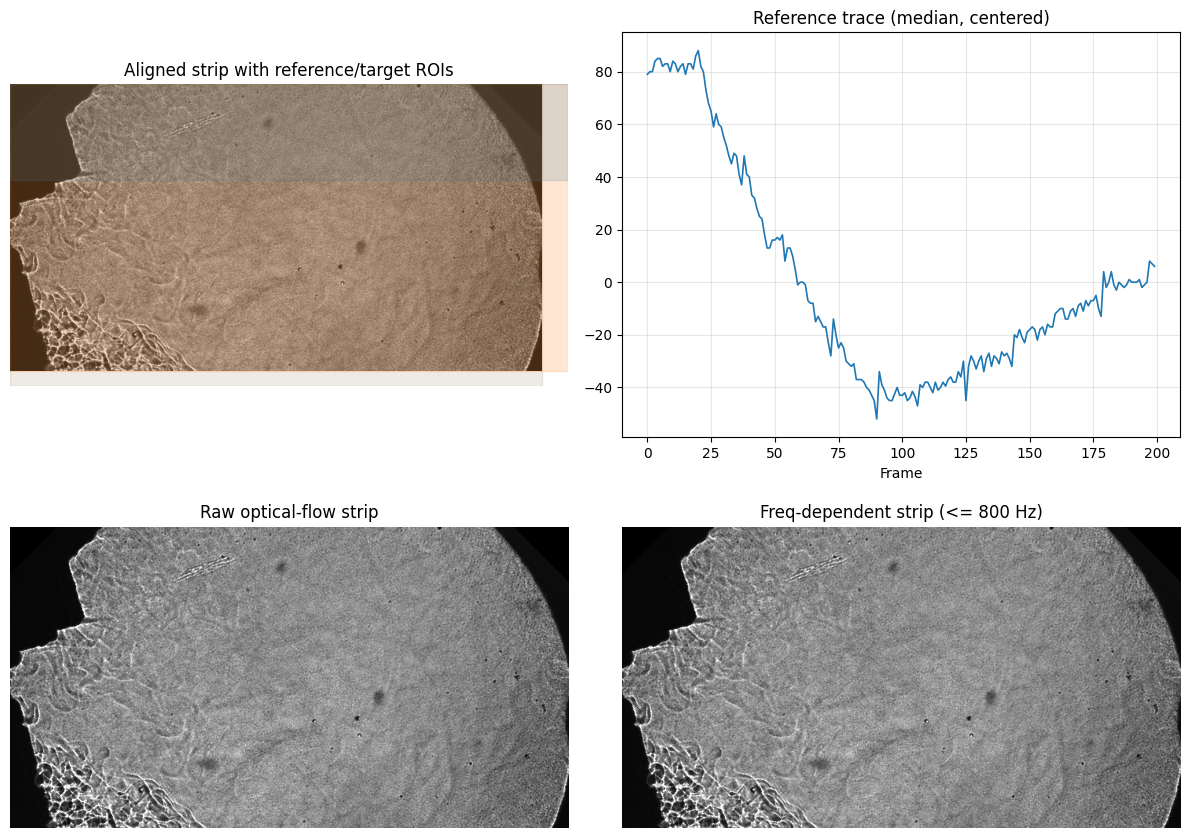

Loaded config: F:\G\Annoyance\config.json
Alignment backend: cupy
aligned_full shape: (200, 384, 711)
video_raw shape: (200, 384, 711)
video_processed shape: (200, 384, 711)
pair_index: 36


In [84]:
video_loaded = load_cine_video(str(CINE_PATH), frame_limit=FRAME_LIMIT)
config, config_path = load_processing_config(CINE_PATH)
aligned_full, alignment_backend = build_aligned_strip(
    video_loaded,
    config,
    strip_relative_height=VIDEO_STRIP_RELATIVE_HEIGHT,
)

target_row_slice = normalize_slice(TARGET_ROW_SLICE, aligned_full.shape[1])
target_col_slice = normalize_slice(TARGET_COL_SLICE, aligned_full.shape[2])

if REFERENCE_ROW_SLICE is None:
    default_ref_stop = max(1, aligned_full.shape[1] // 3)
    reference_row_slice = slice(0, default_ref_stop)
else:
    reference_row_slice = normalize_slice(REFERENCE_ROW_SLICE, aligned_full.shape[1])
reference_col_slice = normalize_slice(REFERENCE_COL_SLICE, aligned_full.shape[2])

video_raw = aligned_full[:, target_row_slice, target_col_slice].astype(np.float32, copy=False)
reference_region = aligned_full[:, reference_row_slice, reference_col_slice].astype(np.float32, copy=False)
reference_trace = region_reference_trace(reference_region, reducer=REFERENCE_TRACE_REDUCER)
video_processed, freq_gain, gain_freqs = frequency_dependent_reference_subtract(
    video_raw,
    reference_trace,
    fps=FPS,
    chunk_pixels=CHUNK_PIXELS,
    smooth_bins=FREQ_DEPENDENT_SMOOTH_BINS,
    max_subtract_hz=FREQ_SUBTRACT_MAX_HZ,
)

video_raw_norm = robust_scale(video_raw, q_min=FLOW_NORMALIZE_Q_MIN, q_max=FLOW_NORMALIZE_Q_MAX).astype(np.float32, copy=False)
video_processed_norm = robust_scale(video_processed, q_min=FLOW_NORMALIZE_Q_MIN, q_max=FLOW_NORMALIZE_Q_MAX).astype(np.float32, copy=False)

pair_limit = video_raw.shape[0] - 2
pair_index = min(max(0, PAIR_INDEX), max(0, pair_limit))

raw0 = video_raw[0]
processed0 = video_processed[0]
aligned0 = aligned_full[0]
target_r0, target_r1 = slice_bounds(target_row_slice, aligned_full.shape[1])
target_c0, target_c1 = slice_bounds(target_col_slice, aligned_full.shape[2])
ref_r0, ref_r1 = slice_bounds(reference_row_slice, aligned_full.shape[1])
ref_c0, ref_c1 = slice_bounds(reference_col_slice, aligned_full.shape[2])

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].imshow(display_frame(aligned0), cmap="gray")
axes[0, 0].axhspan(ref_r0, ref_r1, color="tab:blue", alpha=0.18)
axes[0, 0].axvspan(ref_c0, ref_c1, color="tab:blue", alpha=0.08)
axes[0, 0].axhspan(target_r0, target_r1, color="tab:orange", alpha=0.18)
axes[0, 0].axvspan(target_c0, target_c1, color="tab:orange", alpha=0.08)
axes[0, 0].set_title("Aligned strip with reference/target ROIs")
axes[0, 0].axis("off")

axes[0, 1].plot(reference_trace - reference_trace.mean(), lw=1.2)
axes[0, 1].set_title(f"Reference trace ({REFERENCE_TRACE_REDUCER}, centered)")
axes[0, 1].set_xlabel("Frame")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].imshow(display_frame(raw0), cmap="gray")
axes[1, 0].set_title("Raw optical-flow strip")
axes[1, 0].axis("off")

axes[1, 1].imshow(display_frame(processed0), cmap="gray")
axes[1, 1].set_title(f"Freq-dependent strip (<= {FREQ_SUBTRACT_MAX_HZ:.0f} Hz)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

print(f"Loaded config: {config_path}")
print(f"Alignment backend: {alignment_backend}")
print("aligned_full shape:", aligned_full.shape)
print("video_raw shape:", video_raw.shape)
print("video_processed shape:", video_processed.shape)
print("pair_index:", pair_index)


## Prepare backend inputs


In [85]:
video_raw_input = prepare_video_for_backend(video_raw_norm, BACKEND)
video_processed_input = prepare_video_for_backend(video_processed_norm, BACKEND)

print("raw input:", type(video_raw_input), getattr(video_raw_input, "dtype", None), video_raw_input.shape)
print("processed input:", type(video_processed_input), getattr(video_processed_input, "dtype", None), video_processed_input.shape)


raw input: <class 'numpy.ndarray'> float32 (200, 384, 711)
processed input: <class 'numpy.ndarray'> float32 (200, 384, 711)


## Compute optical flow


In [86]:
t0 = time.time()
flows_raw = compute_optical_flows(
    video_raw_input,
    backend=BACKEND,
    out_hw_last=True,
    **BACKEND_KWARGS,
)
elapsed_raw = time.time() - t0

t0 = time.time()
flows_processed = compute_optical_flows(
    video_processed_input,
    backend=BACKEND,
    out_hw_last=True,
    **BACKEND_KWARGS,
)
elapsed_processed = time.time() - t0

if cp is not None and isinstance(flows_raw, cp.ndarray):
    flows_raw_np = cp.asnumpy(flows_raw)
else:
    flows_raw_np = np.asarray(flows_raw)

if cp is not None and isinstance(flows_processed, cp.ndarray):
    flows_processed_np = cp.asnumpy(flows_processed)
else:
    flows_processed_np = np.asarray(flows_processed)

print("backend:", BACKEND)
print("raw flow shape:", flows_raw_np.shape, flows_raw_np.dtype, f"elapsed={elapsed_raw:.3f}s")
print("processed flow shape:", flows_processed_np.shape, flows_processed_np.dtype, f"elapsed={elapsed_processed:.3f}s")


backend: raft
raw flow shape: (199, 384, 711, 2) float32 elapsed=8.789s
processed flow shape: (199, 384, 711, 2) float32 elapsed=8.592s


In [87]:
from OSCC_postprocessing.utils.scaling import min_max_scale
from OSCC_postprocessing.playback.video_playback import play_videos_side_by_side

raw_mag = np.sqrt(flows_raw_np[..., 0] ** 2 + flows_raw_np[..., 1] ** 2)
processed_mag = np.sqrt(flows_processed_np[..., 0] ** 2 + flows_processed_np[..., 1] ** 2)

play_videos_side_by_side(
    (
        np.squeeze(robust_scale(raw_mag)),
        np.squeeze(robust_scale(processed_mag)),
    )
)


## Visualize one frame pair


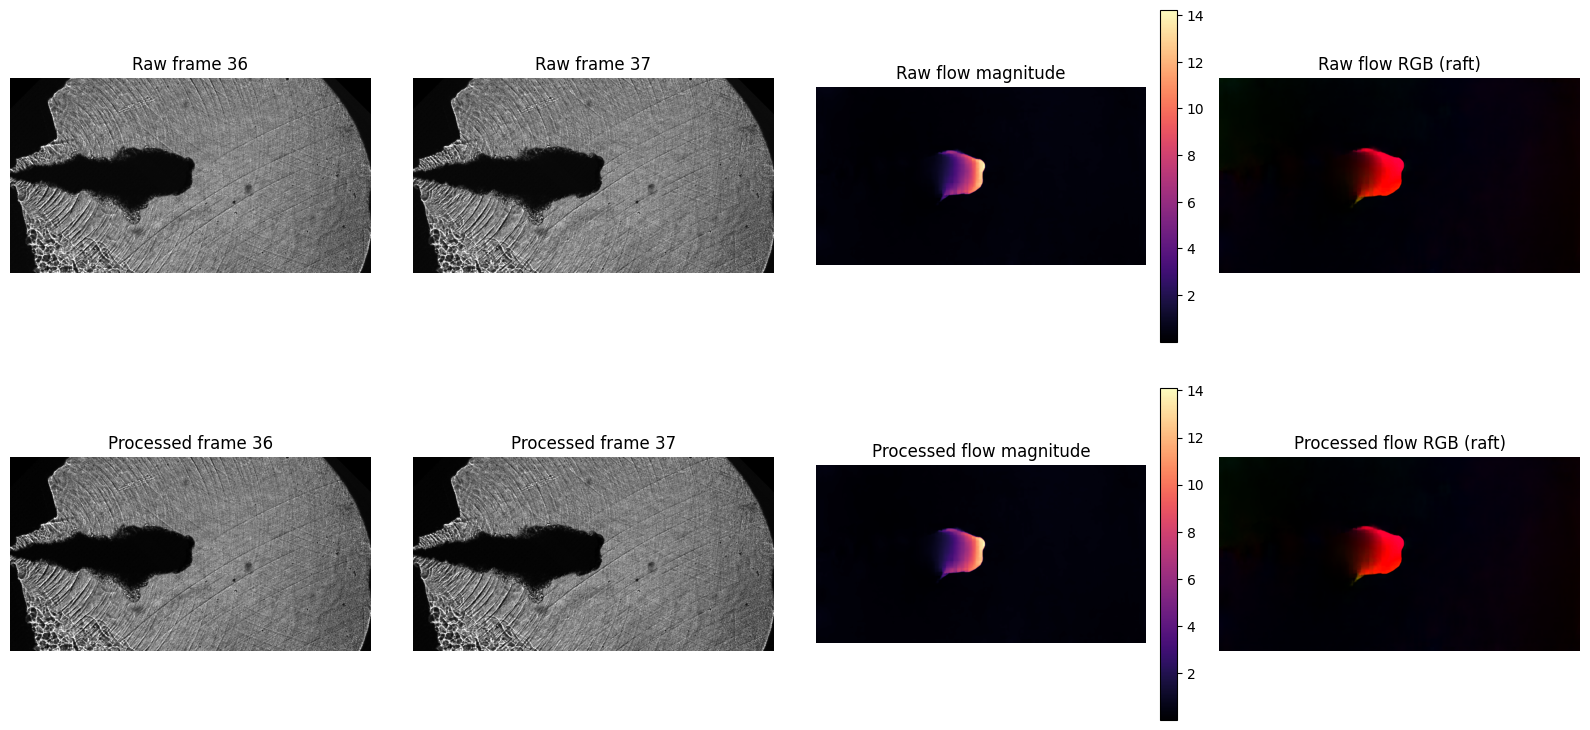

In [88]:
raw_frame_a = video_raw_norm[pair_index]
raw_frame_b = video_raw_norm[pair_index + 1]
processed_frame_a = video_processed_norm[pair_index]
processed_frame_b = video_processed_norm[pair_index + 1]

raw_flow = flows_raw_np[pair_index]
processed_flow = flows_processed_np[pair_index]

raw_mag = flow_magnitude(raw_flow)
processed_mag = flow_magnitude(processed_flow)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes[0, 0].imshow(raw_frame_a, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title(f"Raw frame {pair_index}")
axes[0, 1].imshow(raw_frame_b, cmap="gray", vmin=0, vmax=1)
axes[0, 1].set_title(f"Raw frame {pair_index + 1}")
im0 = axes[0, 2].imshow(raw_mag, cmap="magma")
axes[0, 2].set_title("Raw flow magnitude")
plt.colorbar(im0, ax=axes[0, 2], fraction=0.046, pad=0.04)
axes[0, 3].imshow(flow_to_rgb(raw_flow))
axes[0, 3].set_title(f"Raw flow RGB ({BACKEND})")

axes[1, 0].imshow(processed_frame_a, cmap="gray", vmin=0, vmax=1)
axes[1, 0].set_title(f"Processed frame {pair_index}")
axes[1, 1].imshow(processed_frame_b, cmap="gray", vmin=0, vmax=1)
axes[1, 1].set_title(f"Processed frame {pair_index + 1}")
im1 = axes[1, 2].imshow(processed_mag, cmap="magma")
axes[1, 2].set_title("Processed flow magnitude")
plt.colorbar(im1, ax=axes[1, 2], fraction=0.046, pad=0.04)
axes[1, 3].imshow(flow_to_rgb(processed_flow))
axes[1, 3].set_title(f"Processed flow RGB ({BACKEND})")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()


## Quiver overlay


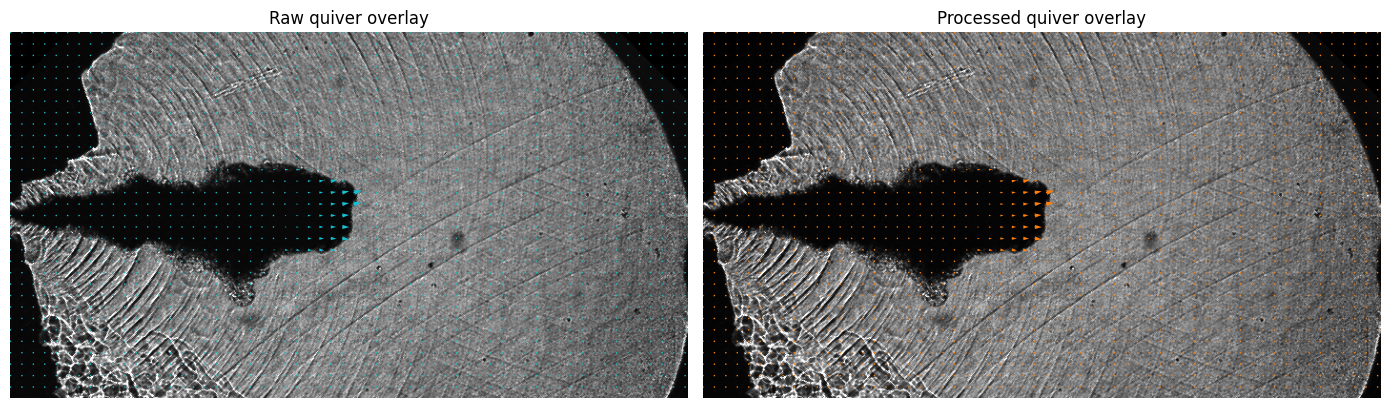

In [89]:
QUIVER_STRIDE = 12

yy, xx = np.mgrid[0:raw_flow.shape[0], 0:raw_flow.shape[1]]
sample = (slice(None, None, QUIVER_STRIDE), slice(None, None, QUIVER_STRIDE))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(raw_frame_a, cmap="gray", vmin=0, vmax=1)
axes[0].quiver(
    xx[sample], yy[sample],
    raw_flow[..., 0][sample], raw_flow[..., 1][sample],
    color="tab:cyan", angles="xy", scale_units="xy", scale=1.5, width=0.0025,
)
axes[0].set_title("Raw quiver overlay")
axes[0].axis("off")

axes[1].imshow(processed_frame_a, cmap="gray", vmin=0, vmax=1)
axes[1].quiver(
    xx[sample], yy[sample],
    processed_flow[..., 0][sample], processed_flow[..., 1][sample],
    color="tab:orange", angles="xy", scale_units="xy", scale=1.5, width=0.0025,
)
axes[1].set_title("Processed quiver overlay")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## Quick summary over time


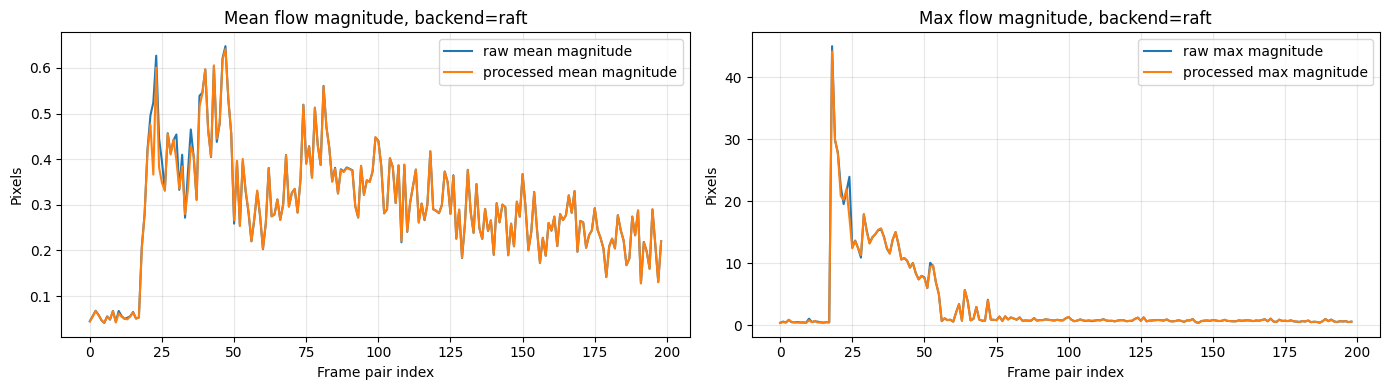

Average mean flow magnitude: raw=0.298465, processed=0.295917, delta=-0.85%


In [90]:
magnitudes_raw = np.linalg.norm(flows_raw_np, axis=-1)
magnitudes_processed = np.linalg.norm(flows_processed_np, axis=-1)

mean_mag_raw = magnitudes_raw.mean(axis=(1, 2))
max_mag_raw = magnitudes_raw.max(axis=(1, 2))
mean_mag_processed = magnitudes_processed.mean(axis=(1, 2))
max_mag_processed = magnitudes_processed.max(axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(mean_mag_raw, label="raw mean magnitude")
axes[0].plot(mean_mag_processed, label="processed mean magnitude")
axes[0].set_xlabel("Frame pair index")
axes[0].set_ylabel("Pixels")
axes[0].set_title(f"Mean flow magnitude, backend={BACKEND}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(max_mag_raw, label="raw max magnitude")
axes[1].plot(max_mag_processed, label="processed max magnitude")
axes[1].set_xlabel("Frame pair index")
axes[1].set_ylabel("Pixels")
axes[1].set_title(f"Max flow magnitude, backend={BACKEND}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

raw_mean = float(mean_mag_raw.mean())
processed_mean = float(mean_mag_processed.mean())
delta_pct = 100.0 * (processed_mean - raw_mean) / max(raw_mean, 1e-8)
print(f"Average mean flow magnitude: raw={raw_mean:.6f}, processed={processed_mean:.6f}, delta={delta_pct:+.2f}%")


## Playback: raw vs processed inputs and flow magnitudes


In [ ]:
raw_flow_mag_display = robust_scale(magnitudes_raw.astype(np.float32), q_min=1.0, q_max=99.5)


Left: raw normalized strip | Right: processed normalized strip
Left: raw flow magnitude | Right: processed flow magnitude


In [ ]:

print("Left: raw normalized strip | Right: processed normalized strip")
play_videos_side_by_side((video_raw_norm, video_processed_norm), intv=PLAYBACK_INTV_MS)


In [96]:
processed_flow_mag_display = robust_scale(magnitudes_processed.astype(np.float32), q_min=10.0, q_max=99)

print("Left: raw flow magnitude | Right: processed flow magnitude")
play_videos_side_by_side((raw_flow_mag_display, processed_flow_mag_display), intv=PLAYBACK_INTV_MS)


Left: raw flow magnitude | Right: processed flow magnitude


## Reference sanity check


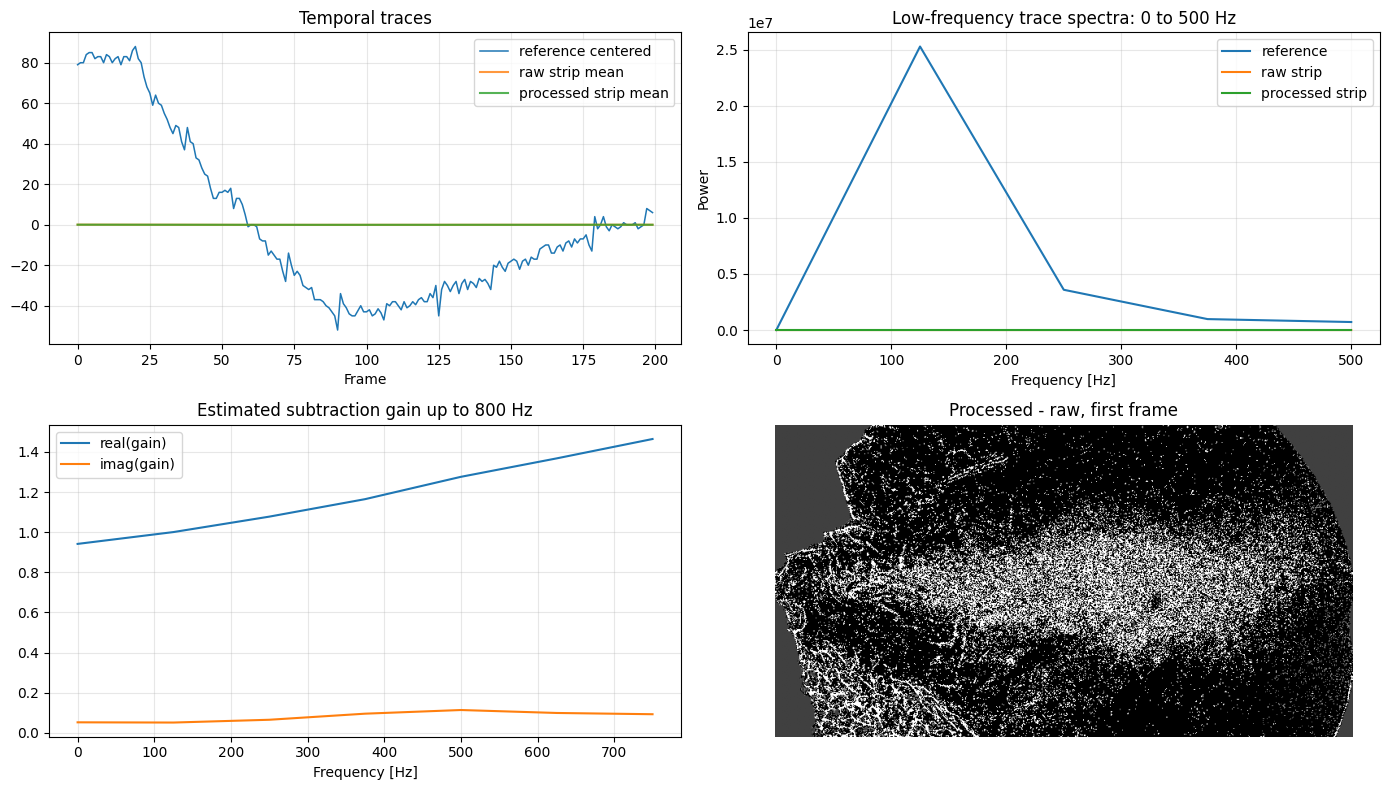

In [92]:
raw_trace = region_reference_trace(video_raw_norm, reducer="mean")
processed_trace = region_reference_trace(video_processed_norm, reducer="mean")
reference_centered = reference_trace - reference_trace.mean()

trace_freqs, reference_power = trace_power_spectrum(reference_trace, FPS)
_, raw_trace_power = trace_power_spectrum(raw_trace, FPS)
_, processed_trace_power = trace_power_spectrum(processed_trace, FPS)
low_freq_mask = trace_freqs <= 500
gain_mask = gain_freqs <= max(FREQ_SUBTRACT_MAX_HZ, 1.0)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(reference_centered, label="reference centered", lw=1.1)
axes[0, 0].plot(raw_trace - raw_trace.mean(), label="raw strip mean", alpha=0.8)
axes[0, 0].plot(processed_trace - processed_trace.mean(), label="processed strip mean", alpha=0.8)
axes[0, 0].set_title("Temporal traces")
axes[0, 0].set_xlabel("Frame")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(trace_freqs[low_freq_mask], reference_power[low_freq_mask], label="reference")
axes[0, 1].plot(trace_freqs[low_freq_mask], raw_trace_power[low_freq_mask], label="raw strip")
axes[0, 1].plot(trace_freqs[low_freq_mask], processed_trace_power[low_freq_mask], label="processed strip")
axes[0, 1].set_title("Low-frequency trace spectra: 0 to 500 Hz")
axes[0, 1].set_xlabel("Frequency [Hz]")
axes[0, 1].set_ylabel("Power")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(gain_freqs[gain_mask], np.real(freq_gain)[gain_mask], label="real(gain)")
axes[1, 0].plot(gain_freqs[gain_mask], np.imag(freq_gain)[gain_mask], label="imag(gain)")
axes[1, 0].set_title(f"Estimated subtraction gain up to {FREQ_SUBTRACT_MAX_HZ:.0f} Hz")
axes[1, 0].set_xlabel("Frequency [Hz]")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].imshow(display_frame(video_processed[0] - video_raw[0], q_min=1.0, q_max=99.5), cmap="gray")
axes[1, 1].set_title("Processed - raw, first frame")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()
